# 👥 Customer Segmentation with K-Means

**Goal:** group mall customers into segments so the marketing team can target each group differently.

We use **K-Means clustering** — an **unsupervised** learning algorithm.
Unsupervised = the data has **no labels**. There is no "correct answer" column.
So we cannot compute accuracy. Instead, we judge clusters by: are they clearly separated and do they make business sense?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

%matplotlib inline
sns.set_theme(style="whitegrid")

## Step 1: Load the data

Each row = one customer. We will segment on **AnnualIncome_k** (income in thousands) and **SpendingScore** (1-100).

In [2]:
df = pd.read_csv("data/mall_customers.csv")
print(df.head())
print("\nShape:", df.shape)
print(df.describe())

   CustomerID  Age  AnnualIncome_k  SpendingScore
0        1861   57              25             26
1         354   28              37             74
2        1334   26              87             71
3         906   45              55             55
4        1290   33              92             79

Shape: (2000, 4)
        CustomerID          Age  AnnualIncome_k  SpendingScore
count  2000.000000  2000.000000     2000.000000    2000.000000
mean   1000.500000    43.788000       54.511500      49.691000
std     577.494589    17.018339       28.551803      27.998955
min       1.000000    18.000000       15.000000       1.000000
25%     500.750000    27.000000       25.000000      21.000000
50%    1000.500000    41.500000       55.000000      52.000000
75%    1500.250000    61.000000       84.000000      77.000000
max    2000.000000    75.000000      108.000000     100.000000


## Step 2: Look at the raw data first

Before clustering, always plot. The scatter below already hints at natural groups.

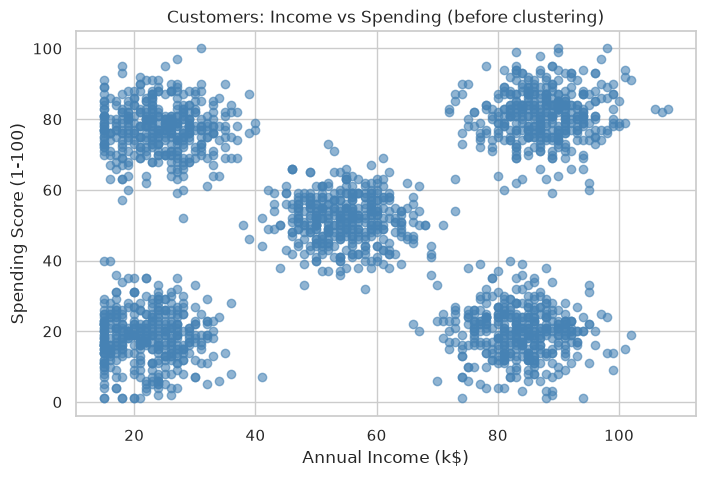

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(df["AnnualIncome_k"], df["SpendingScore"], alpha=0.6, color="steelblue")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customers: Income vs Spending (before clustering)")
plt.show()

## Step 3: Elbow method — how many clusters?

We try k = 1..8 and plot **inertia** (sum of squared distances to cluster centers).
Inertia always drops as k grows. The "elbow" — where the drop slows sharply — is a good k.
Here the elbow is clearly at **k = 5**.

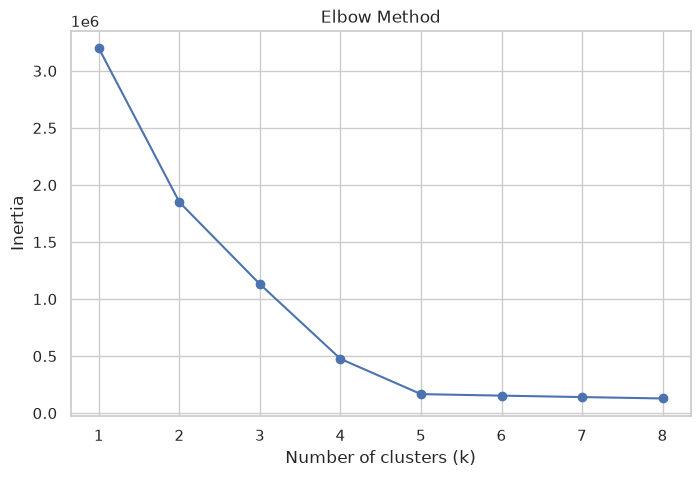

In [4]:
X = df[["AnnualIncome_k", "SpendingScore"]]

inertias = []
for k in range(1, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 9), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(range(1, 9))
plt.show()

## Step 4: Fit K-Means with k = 5

- `random_state=42` → same result every run (reproducible).
- `n_init=10` → algorithm tries 10 different starting points, keeps the best.

In [5]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X)

print("Cluster sizes:")
print(df["Cluster"].value_counts().sort_index())
print("\nCluster centers (income, spending):")
print(kmeans.cluster_centers_.round(1))

Cluster sizes:
Cluster
0    400
1    400
2    400
3    400
4    400
Name: count, dtype: int64

Cluster centers (income, spending):
[[87.6 81.4]
 [22.1 18.3]
 [24.4 77.5]
 [54.8 51.7]
 [83.7 19.6]]


## Step 5: Visualize the clusters

Each color = one segment. The ✕ marks are the cluster centers.

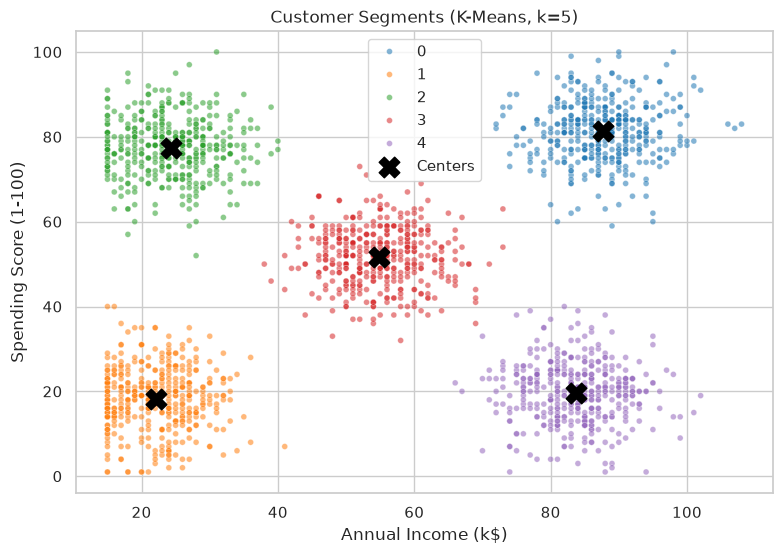

In [6]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="AnnualIncome_k", y="SpendingScore",
                hue="Cluster", palette="tab10", s=18, alpha=0.55)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], marker="X", s=220,
            color="black", label="Centers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments (K-Means, k=5)")
plt.legend()
plt.show()

## Step 6: Profile each cluster 🧾

Average age, income and spending per cluster — this is what makes clusters *useful*:

In [7]:
profile = df.groupby("Cluster").agg(
    Count=("CustomerID", "count"),
    AvgAge=("Age", "mean"),
    AvgIncome_k=("AnnualIncome_k", "mean"),
    AvgSpending=("SpendingScore", "mean"),
).round(1)
print(profile)

         Count  AvgAge  AvgIncome_k  AvgSpending
Cluster                                         
0          400    27.3         87.6         81.4
1          400    61.2         22.1         18.3
2          400    24.5         24.4         77.5
3          400    41.7         54.8         51.7
4          400    64.2         83.7         19.6


### What each cluster means (plain words)

- **Cluster 0 — Careful savers:** older customers, high income, but low spending. They *can* buy but don't. Strategy: loyalty programs, premium service to win their trust.
- **Cluster 1 — Standard customers:** mid-age, mid income, mid spending. The average shopper. Strategy: regular promotions, keep them happy.
- **Cluster 2 — Budget youngsters:** young, low income, but high spending score. They spend a big share of what they earn. Strategy: discounts, trendy products, social media ads.
- **Cluster 3 — Premium targets 🎯:** young, high income, high spending. The dream customers! Strategy: VIP treatment, new arrivals, exclusive offers.
- **Cluster 4 — Low priority:** older, low income, low spending. Strategy: don't waste the marketing budget here.

> 💡 Note: cluster numbers are arbitrary — K-Means just labels them 0-4. The *meaning* comes from profiling, not the number.

### Key takeaway
This is **unsupervised learning** — there were no labels, and there is no accuracy score.
The value is insight: 5 clear, explainable customer groups the business can act on. ✅